# Hybrid QNN Performance on BCCC-CIC-IDS-2017

This notebook loads the trained Hybrid QNN model and evaluates its performance using various metrics and visualizations.

In [1]:
import pandas as pd
import numpy as np
import os
import torch
import torch.nn as nn
import pennylane as qml
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

## 1. Load Data & Configuration

In [2]:
# Configuration
DATASET_PATH = 'Datasets/processed_data.csv'
MODEL_PATH = 'trained_model/hybrid_qnn_ids2017.pth'
BATCH_SIZE = 32
N_QUBITS = 4
N_LAYERS = 2
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

# Load Data
print("Loading dataset...")
if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(f"Dataset not found at {DATASET_PATH}.")

df = pd.read_csv(DATASET_PATH)
print(f"Total samples: {len(df)}")

# Separate Features and Target
X = df.drop(columns=['label']).values
y = df['label'].values

num_classes = len(np.unique(y))
print(f"Number of classes: {num_classes}")

# Train/Test Split (Must match training split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

# Convert to PyTorch Tensors
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Data Loader
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Testing samples: {len(X_test)}")

Loading dataset...
Total samples: 840549
Number of classes: 14
Testing samples: 168110


## 2. Define Model Architecture
Must match the training architecture exactly.

In [3]:
# Quantum Device
dev = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev, interface="torch")
def qnn_layer(inputs, weights):
    # Encode classical data (Angle Embedding)
    for i in range(N_QUBITS):
        qml.RX(inputs[i], wires=i)

    # Variational layers
    qml.templates.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
    
    # Measurement
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

class HybridQNN(nn.Module):
    def __init__(self, input_dim, n_qubits, n_layers, output_dim):
        super().__init__()
        self.n_qubits = n_qubits
        
        # Classical Projection Layer: Reduces input_dim -> n_qubits
        self.projection = nn.Linear(input_dim, n_qubits)
        
        # Quantum Weights
        self.q_weights = nn.Parameter(
            0.01 * torch.randn(n_layers, n_qubits, 3)
        )
        
        # Classical Output Head
        self.fc = nn.Linear(n_qubits, output_dim)

    def forward(self, x):
        # 1. Project High-Dim Features -> Qubits
        x_proj = torch.tanh(self.projection(x)) * np.pi # Scale to [-pi, pi]
        
        # 2. Quantum Layer
        q_out = []
        for sample in x_proj:
            q = qnn_layer(sample, self.q_weights)
            q = torch.stack(q) 
            q_out.append(q)
        
        q_out = torch.stack(q_out).float()
        
        # 3. Final Classification
        return self.fc(q_out)

## 3. Load Model & Evaluate

In [4]:
input_dim = X_test.shape[1]
output_dim = 1 if num_classes == 2 else num_classes

model = HybridQNN(input_dim, N_QUBITS, N_LAYERS, output_dim)

if os.path.exists(MODEL_PATH):
    model.load_state_dict(torch.load(MODEL_PATH))
    print(f"Loaded model from {MODEL_PATH}")
else:
    raise FileNotFoundError(f"Model file not found at {MODEL_PATH}")

model.eval()
all_preds = []
all_labels = []

print("Running inference...")
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        logits = model(X_batch)
        if num_classes == 2:
            preds = torch.sigmoid(logits) > 0.5
        else:
            preds = torch.argmax(logits, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

print("Done.")

Loaded model from trained_model/hybrid_qnn_ids2017.pth
Running inference...
Done.


## 4. Visualizations & Metrics

<Figure size 1200x1000 with 0 Axes>

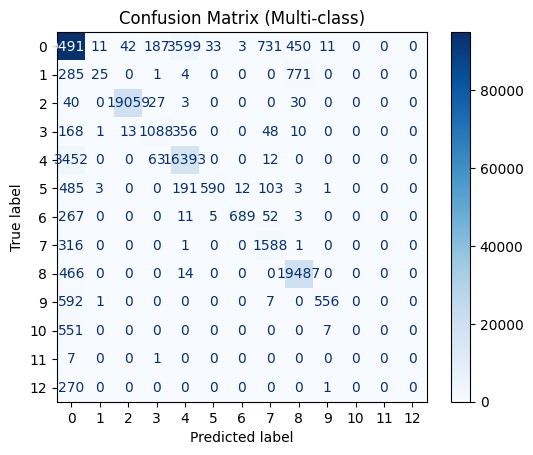

In [5]:
# 4.1 Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix (Multi-class)")
plt.show()

In [6]:
# 4.2 Classification Report
print("Classification Report:")
print(classification_report(all_labels, all_preds, zero_division=0))

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94     99980
           1       0.61      0.02      0.04      1086
           2       1.00      0.99      1.00     19159
           3       0.80      0.65      0.71      1684
           4       0.80      0.82      0.81     19920
           5       0.94      0.43      0.59      1388
           6       0.98      0.67      0.80      1027
           7       0.62      0.83      0.71      1906
           9       0.94      0.98      0.96     19967
          10       0.97      0.48      0.64      1156
          11       0.00      0.00      0.00       558
          12       0.00      0.00      0.00         8
          13       0.00      0.00      0.00       271

    accuracy                           0.92    168110
   macro avg       0.66      0.52      0.55    168110
weighted avg       0.91      0.92      0.91    168110



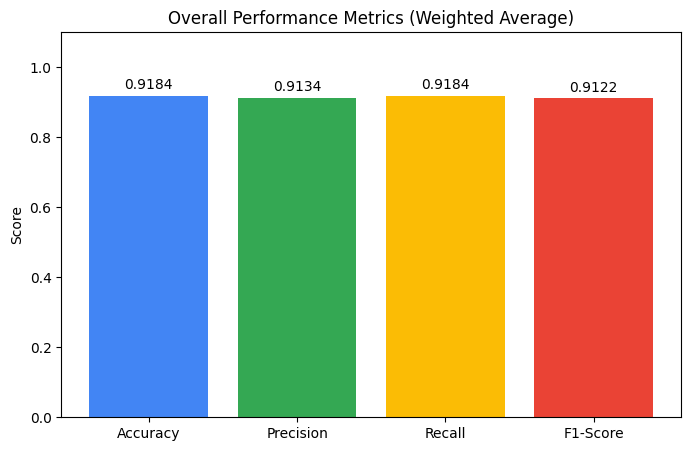

In [7]:
# 4.3 Performance Metrics Bar Plot
average_type = 'binary' if num_classes == 2 else 'weighted'
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average=average_type, zero_division=0)
rec = recall_score(all_labels, all_preds, average=average_type, zero_division=0)
f1 = f1_score(all_labels, all_preds, average=average_type, zero_division=0)

metrics = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}
names = list(metrics.keys())
values = list(metrics.values())

plt.figure(figsize=(8, 5))
bars = plt.bar(names, values, color=['#4285F4', '#34A853', '#FBBC05', '#EA4335'])
plt.ylim(0, 1.1)
plt.title(f"Overall Performance Metrics ({average_type.capitalize()} Average)")
plt.ylabel("Score")

# Add text labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 4), ha='center', va='bottom')

plt.show()

<Figure size 600x500 with 0 Axes>

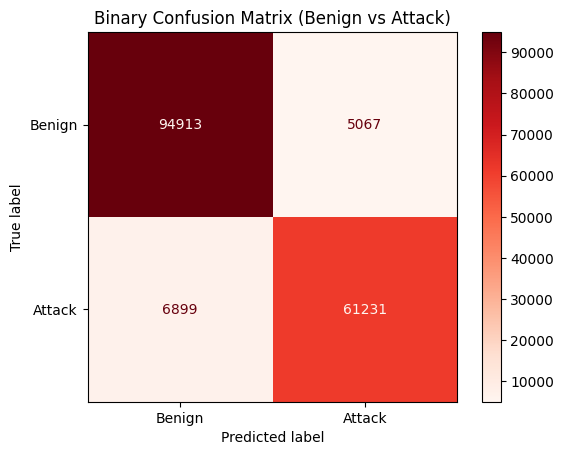

Binary Classification Report:
              precision    recall  f1-score   support

      Benign       0.93      0.95      0.94     99980
      Attack       0.92      0.90      0.91     68130

    accuracy                           0.93    168110
   macro avg       0.93      0.92      0.93    168110
weighted avg       0.93      0.93      0.93    168110



In [8]:
# 4.4 Binary Confusion Matrix (Benign vs Attack)
# Benign is class 0, all others are Attack
binary_labels = [0 if y == 0 else 1 for y in all_labels]
binary_preds = [0 if p == 0 else 1 for p in all_preds]

cm_binary = confusion_matrix(binary_labels, binary_preds)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_binary, display_labels=['Benign', 'Attack'])
disp.plot(cmap=plt.cm.Reds, values_format='d')
plt.title("Binary Confusion Matrix (Benign vs Attack)")
plt.show()

print("Binary Classification Report:")
print(classification_report(binary_labels, binary_preds, target_names=['Benign', 'Attack'], zero_division=0))